In [6]:
import math
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics, FlattenObservation
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("Blackjack-v1", sab=True)  # using the blackjack environment; "sab" allows card counting if needed
env = FlattenObservation(env)  # Wrap to flatten the observation space
check_env(env)
model = PPO.load("model", env=env)

# Evaluation settings
N_TEST_EPISODES = 100_000
win, loss, draw = 0, 0, 0
cumulative_reward_eval = 0
total_bets_eval = 0

for _ in range(N_TEST_EPISODES):
    state, _ = env.reset()
    
    # As in training, take an initial step to handle any immediate termination.
    action, _ = model.predict(state, deterministic=True)
    next_state, reward, done, truncated, _ = env.step(action)
    # If the episode ends immediately, record the pseudo-transition.
    if done:
        final_reward = reward
    else:
        state = next_state
        while not done:
            action, _ = model.predict(state, deterministic=True)
            state, reward, done, truncated, _ = env.step(action)
        final_reward = reward
    
    cumulative_reward_eval += final_reward
    total_bets_eval += 1
    if final_reward > 0:
        win += 1
    elif final_reward < 0:
        loss += 1
    else:
        draw += 1

win_perc = (win / N_TEST_EPISODES) * 100
loss_perc = (loss / N_TEST_EPISODES) * 100
draw_perc = (draw / N_TEST_EPISODES) * 100
avg_reward_eval = (cumulative_reward_eval / total_bets_eval) * 100  # expressed as a percentage

print("\nEvaluation over", N_TEST_EPISODES, "episodes:")
print(f"Win %: {win_perc:.2f}%")
print(f"Loss %: {loss_perc:.2f}%")
print(f"Draw %: {draw_perc:.2f}%")
print(f"Average Reward per Bet (%): {avg_reward_eval:.2f}%")

/mnt/50BE87BDBE879A5C/blackjack/ppo/venv/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
/mnt/50BE87BDBE879A5C/blackjack/ppo/venv/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
/mnt/50BE87BDBE879A5C/blackjack/ppo/venv/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(



Evaluation over 100000 episodes:
Win %: 43.12%
Loss %: 47.70%
Draw %: 9.18%
Average Reward per Bet (%): -4.57%


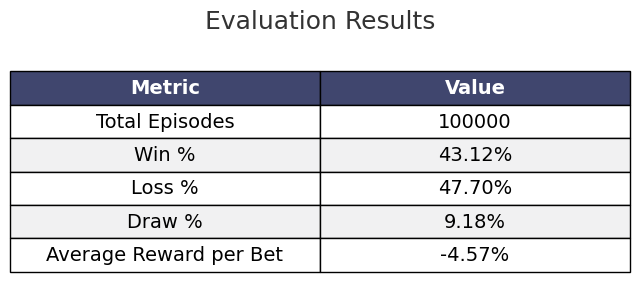

In [8]:
# Assuming these variables are already computed from your evaluation:
# N_TEST_EPISODES, win_perc, loss_perc, draw_perc, avg_reward_eval

# Prepare table data
table_data = [
    ["Total Episodes", N_TEST_EPISODES],
    ["Win %", f"{win_perc:.2f}%"],
    ["Loss %", f"{loss_perc:.2f}%"],
    ["Draw %", f"{draw_perc:.2f}%"],
    ["Average Reward per Bet", f"{avg_reward_eval:.2f}%"]
]

# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')  # Turn off the axis

# Create the table and customize it
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"],
                 cellLoc='center', loc='center')

# Adjust table style
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2)

# Color the header and rows for a beautiful look
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_facecolor("#40466e")
        cell.set_text_props(color="w", weight="bold")
    else:
        # Alternate row colors for a more colorful effect
        if row % 2 == 0:
            cell.set_facecolor("#f1f1f2")
        else:
            cell.set_facecolor("#ffffff")

# Set a title with custom styling
plt.title("Evaluation Results", fontsize=18, color="#333333", pad=20)

plt.show()